# 12-vtrain4 — TCN: Wider TBM Labels + Spot/Futures Routing

## What changed vs vtrain3

| # | vtrain3 (broken) | vtrain4 (fixed) |
|---|------------------|-----------------|
| 1 | TBM barriers at 1×σ → 2 000–3 770 OOS trades | **TBM barriers ±2×ATR, 24h vertical** → fewer, wider trades aligned with vtrain7 LGBM |
| 2 | All trades through Futures → longs charged funding | **Spot/Futures routing**: longs→Spot (0% funding), shorts→Futures (receive funding) |
| 3 | Architecture grid search over channels/dropout | **Fixed at vtrain3 best config**: `[64,64,64,64]` kernel=3 dropout=0.40 |
| 4 | Confidence exit: `max(0.28, threshold − 0.10)` | **vtrain7 convention**: `exit_long = 1 − long_threshold` |

vtrain3 root cause: 1×σ TBM barriers are ~0.2–0.5% wide — any reversion within 12h triggers a round-trip.
Result: even at threshold=0.50, **all 10 368 grid configs had ≥ 2 366 OOS trades**.
Fixing labels to ±2×ATR (≈1–3%) is the same lever that LGBM vtrain7 applied.

**Estimated runtime: ~30–90 min K-Fold (M4 MPS) + ~10 min grid search.**

In [1]:
SYMBOL    = 'BTCUSDT'
INTERVAL  = '1h'
TRAIN_END = '2024-06-01'
VAL_END   = '2024-11-10'

# ── K-Fold (retained from vtrain3) ───────────────────────────────────────────
K                    = 5
EMBARGO              = 168
KFOLD_INTERNAL_VAL_H = 1500
EPOCHS_FOLD          = 60
PATIENCE_FOLD        = 10

# ── TCN architecture — FIXED at vtrain3 best config (no architecture search) ─
SEQ_LEN      = 24
TCN_CHANNELS = [64, 64, 64, 64]
TCN_KERNEL   = 3
TCN_DROPOUT  = 0.40
WARMUP_EPOCHS = 5
BATCH_SIZE   = 256
LR           = 2e-3
WEIGHT_DECAY = 1e-3
LAMBDA_VOL   = 0.5
SEED         = 42

# ── TBM labels — vtrain7 style: wider barriers, fewer but better-quality trades
# vtrain3 used TBM_PT=1.0×σ (≈0.2–0.5%): too tight, generated 2k+ trades on OOS
# vtrain7 LGBM used 2.0×ATR (≈1–3%): produces fewer signals with real edge
TBM_ATR_MULT   = 2.0   # barrier width = ATR * TBM_ATR_MULT (same as vtrain7 LGBM)
TBM_VERT_H     = 24    # vertical barrier: 24h (same as vtrain7 LGBM)
AUX_FWD_H      = 6

# ── Execution: Spot/Futures routing (vtrain7 improvement) ────────────────────
MAKER_FEE         = 0.0000     # 0%    — limit-order entries + TP exits
SPOT_TAKER_FEE    = 0.0005     # 0.05% — Spot SL/time exits (longs)
FUTURES_TAKER_FEE = 0.0005     # 0.05% — Futures SL/time exits (shorts)
BUFFER            = 0.0005     # 5bp wick-penetration FIFO fill guarantee
SPOT_FUNDING_H    = 0.0        # Spot longs: zero funding drag
SHORT_FUNDING_H   = 0.0000077  # Futures shorts: +0.00077%/h RECEIVED

# ── Grid search ───────────────────────────────────────────────────────────────
# Wider thresholds than vtrain3 (0.40–0.55 vs 0.38–0.50) since wider TBM
# barriers should shift the model's P(up)/P(down) distributions higher
TRADING_GRID = {
    'long_threshold':    [0.40, 0.45, 0.50, 0.55],
    'short_threshold':   [0.40, 0.45, 0.50, 0.55],
    'entry_atr_mult':    [0.3, 0.6, 1.0],
    'sl_atr_multiplier': [1.5, 2.0, 2.5],
    'tp_atr_multiplier': [2.0, 2.5, 3.0],
    'min_sl':            [0.010, 0.015],
    'min_hold':          [4, 8],
    'max_hold':          [24, 48],
    'cooldown':          [2, 3],
}

FRAC_D    = 0.4
FFD_THRES = 1e-4

MIN_TRADES      = 15
OPTIMISE_METRIC = 'sharpe'
TOP_N           = 20

In [2]:
import itertools
import json
import math
import pickle
import random
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import QuantileTransformer
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

from hmats.data.splits import calendar_split

warnings.filterwarnings('ignore')
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.cuda.is_available():    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built(): DEVICE = torch.device('mps')
else:                            DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350'; GREEN='#26A69A'; PURPLE='#7B1FA2'

REPO_ROOT    = Path.cwd().parents[2]
if not (REPO_ROOT / 'pyproject.toml').exists(): REPO_ROOT = Path.cwd()
FEATURES_DIR = REPO_ROOT / 'data' / 'features'
RAW_DIR      = REPO_ROOT / 'data' / 'raw'
FIGURES_DIR  = REPO_ROOT / 'figures'
MODELS_DIR   = REPO_ROOT / 'local_models'
if not MODELS_DIR.exists(): MODELS_DIR = REPO_ROOT / 'models'
FIGURES_DIR.mkdir(exist_ok=True)
print(f'REPO_ROOT: {REPO_ROOT}  MODELS_DIR: {MODELS_DIR}')
print(f'Maker={MAKER_FEE*100:.2f}%  SpotTaker={SPOT_TAKER_FEE*100:.3f}%  '
      f'FutTaker={FUTURES_TAKER_FEE*100:.3f}%  Buffer={BUFFER*1e4:.0f}bp')
print(f'TBM: ±{TBM_ATR_MULT}×ATR  vert={TBM_VERT_H}h  (vtrain3 was 1×σ, 12h)')

Device: mps
REPO_ROOT: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system  MODELS_DIR: /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/local_models
Maker=0.00%  SpotTaker=0.050%  FutTaker=0.050%  Buffer=5bp
TBM: ±2.0×ATR  vert=24h  (vtrain3 was 1×σ, 12h)


In [3]:
# ── Features + high/low from raw parquet ─────────────────────────────────────
feat_df = pd.read_parquet(FEATURES_DIR / f'{SYMBOL}_{INTERVAL}_features.parquet')
feat_df.index = feat_df.index.tz_localize(None) if feat_df.index.tz else feat_df.index

with open(FEATURES_DIR / 'feature_registry.json') as f:
    BACKTEST_COLS = json.load(f)['backtest_only_cols']

selected_features = pd.read_csv(MODELS_DIR / 'lgbm_features.csv', header=None)[0].tolist()

raw_df = pd.read_parquet(RAW_DIR / f'{SYMBOL}_{INTERVAL}.parquet')
raw_df.index = raw_df.index.tz_localize(None) if raw_df.index.tz else raw_df.index
feat_df = feat_df.join(raw_df[['high', 'low']], how='left')
feat_df = feat_df.dropna(subset=['high', 'low'])

# ── FFD ───────────────────────────────────────────────────────────────────────
def _ffd_weights(d, thres=1e-4):
    w=[1.0]; k=1
    while True:
        w_k=-w[-1]/k*(d-k+1)
        if abs(w_k)<thres: break
        w.append(w_k); k+=1
    return np.array(w[::-1])

def frac_diff_ffd(series, d, thres=1e-4):
    weights=_ffd_weights(d,thres); width=len(weights)
    vals=series.values.astype(np.float64); out=np.full(len(vals),np.nan)
    for i in range(width-1,len(vals)): out[i]=np.dot(weights,vals[i-width+1:i+1])
    return pd.Series(out,index=series.index)

log_close      = np.log(feat_df['close'])
fracdiff_close = frac_diff_ffd(log_close, FRAC_D, FFD_THRES)
feat_df['fracdiff_close'] = fracdiff_close

# ── TBM labels — vtrain7 style: ATR-based barriers, 24h vertical ──────────────
# vtrain3: barriers at 1×rolling_vol (σ) → too tight → 2 000+ OOS trades
# vtrain4: barriers at 2×ATR14 → aligns with what the backtest SL/TP actually uses
close_vals = feat_df['close'].values
high_vals  = feat_df['high'].values
low_vals   = feat_df['low'].values
atr_vals   = feat_df['atr_14_pct'].values   # ATR14 as fraction of close
n          = len(close_vals)
tbm_labels = np.full(n, np.nan)

for i in range(n - TBM_VERT_H):
    atr = atr_vals[i]
    if np.isnan(atr) or atr <= 0: continue
    entry = close_vals[i]
    upper = entry * (1.0 + TBM_ATR_MULT * atr)   # long barrier
    lower = entry * (1.0 - TBM_ATR_MULT * atr)   # short barrier
    lbl = 2   # neutral (vertical barrier)
    for j in range(1, TBM_VERT_H + 1):
        hi = high_vals[i + j]; lo = low_vals[i + j]
        if lo <= lower and hi >= upper: lbl = 2; break   # simultaneous → neutral
        elif lo <= lower:               lbl = 0; break   # class 0 = short
        elif hi >= upper:               lbl = 1; break   # class 1 = long
    tbm_labels[i] = lbl
feat_df['tbm_label'] = tbm_labels

# ── Aux vol target + sample weights (retained from vtrain3) ───────────────────
log_rets  = log_close.diff()
fwd_vol   = pd.concat([log_rets.shift(-h) for h in range(1, AUX_FWD_H+1)], axis=1).std(axis=1)
feat_df['fwd_vol'] = fwd_vol
rolling_vol = log_rets.rolling(24).std()
w_raw = rolling_vol.fillna(rolling_vol.median()) / rolling_vol.median()
feat_df['sample_weight'] = w_raw.clip(0.3, 3.0).fillna(1.0)
feat_df['rolling_vol'] = rolling_vol

# ── Split ─────────────────────────────────────────────────────────────────────
ALL_INPUT_FEATS = selected_features + ['fracdiff_close']
# Deduplicate: atr_14_pct may already be in ALL_INPUT_FEATS or BACKTEST_COLS.
# Duplicate column names cause pandas to return a 2-D DataFrame on single-key
# access, which makes atr_arr[i] return a row array instead of a scalar and
# breaks max(sl_m * atr, min_sl) in the backtest loop with a ValueError.
required_cols = list(dict.fromkeys(
    ALL_INPUT_FEATS + ['tbm_label', 'fwd_vol', 'sample_weight',
                       'rolling_vol', 'high', 'low', 'atr_14_pct'] + BACKTEST_COLS
))
clean_df = feat_df[required_cols].dropna()

train_df, val_df, test_df = calendar_split(clean_df, train_end=TRAIN_END, val_end=VAL_END)

print(f'Train: {len(train_df):>7,}  {train_df.index.min().date()} → {train_df.index.max().date()}')
print(f'Val:   {len(val_df):>7,}  {val_df.index.min().date()} → {val_df.index.max().date()}')
print(f'Test:  {len(test_df):>7,}  {test_df.index.min().date()} → {test_df.index.max().date()}')
print(f'Input features: {len(ALL_INPUT_FEATS)}')

# Label distribution
lbl_counts = train_df['tbm_label'].value_counts().sort_index()
print(f'\nTrain TBM label distribution (0=short, 1=long, 2=neutral):')
for lbl, cnt in lbl_counts.items():
    print(f'  class {int(lbl)}: {cnt:>6,} ({cnt/len(train_df)*100:.1f}%)')

Train:  56,949  2017-11-27 → 2024-06-01
Val:     3,888  2024-06-01 → 2024-11-10
Test:   13,224  2024-11-10 → 2026-05-15
Input features: 51

Train TBM label distribution (0=short, 1=long, 2=neutral):
  class 0: 24,198 (42.5%)
  class 1: 23,782 (41.8%)
  class 2:  8,969 (15.7%)


In [4]:
# ── TCN architecture — identical to vtrain3 (no architecture search) ──────────
class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation):
        super().__init__()
        self.pad  = (kernel-1)*dilation
        self.conv = nn.utils.weight_norm(
            nn.Conv1d(in_ch, out_ch, kernel, dilation=dilation, padding=self.pad))
    def forward(self, x):
        out = self.conv(x)
        return out[:,:,:-self.pad] if self.pad > 0 else out

class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel, dilation, dropout):
        super().__init__()
        self.net = nn.Sequential(
            CausalConv1d(in_ch,out_ch,kernel,dilation), nn.ReLU(True), nn.Dropout(dropout),
            CausalConv1d(out_ch,out_ch,kernel,dilation), nn.ReLU(True), nn.Dropout(dropout),
        )
        self.downsample = nn.Conv1d(in_ch,out_ch,1) if in_ch!=out_ch else None
    def forward(self, x):
        res = self.downsample(x) if self.downsample is not None else x
        return F.relu(self.net(x)+res)

class TCNMultiTask(nn.Module):
    def __init__(self, input_dim, channels, kernel, dropout):
        super().__init__()
        blocks, in_ch = [], input_dim
        for i, ch in enumerate(channels):
            blocks.append(TCNBlock(in_ch,ch,kernel,2**i,dropout)); in_ch=ch
        self.tcn = nn.Sequential(*blocks)
        d = channels[-1]
        self.head_dir = nn.Sequential(
            nn.LayerNorm(d), nn.Linear(d,32), nn.GELU(),
            nn.Dropout(dropout*.5), nn.Linear(32,3))
        self.head_vol = nn.Sequential(
            nn.LayerNorm(d), nn.Linear(d,16), nn.GELU(), nn.Linear(16,1), nn.Softplus())
    def forward(self, x):
        out = self.tcn(x.transpose(1,2)); last = out[:,:,-1]
        return self.head_dir(last), self.head_vol(last).squeeze(-1)

def make_lr_lambda(total_epochs, warmup):
    def lr_lambda(epoch):
        if epoch < warmup: return (epoch+1)/warmup
        progress = (epoch-warmup)/max(1,total_epochs-warmup)
        return 0.5*(1+math.cos(math.pi*progress))
    return lr_lambda

n_params = sum(p.numel() for p in TCNMultiTask(
    len(ALL_INPUT_FEATS), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).parameters())
print(f'TCNMultiTask: {n_params:,} parameters  (architecture identical to vtrain3)')

TCNMultiTask: 103,652 parameters  (architecture identical to vtrain3)


In [5]:
qt = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=SEED)
qt.fit(train_df[ALL_INPUT_FEATS].values)
print(f'QT fitted on train_df: {train_df[ALL_INPUT_FEATS].shape}')

X_train_qt  = qt.transform(train_df[ALL_INPUT_FEATS].values).astype(np.float32)
y_train_all = train_df['tbm_label'].values.astype(np.int64)
w_train_all = train_df['sample_weight'].values.astype(np.float32)
v_train_all = train_df['fwd_vol'].values.astype(np.float32)

train_close = train_df['close'].values.astype(np.float64)
train_high  = train_df['high'].values.astype(np.float64)
train_low   = train_df['low'].values.astype(np.float64)
train_atr   = train_df['atr_14_pct'].values.astype(np.float64)
train_index = train_df.index

N_TRAIN = len(train_df)
print(f'N_TRAIN={N_TRAIN:,}  X_train_qt: {X_train_qt.shape}')

QT fitted on train_df: (56949, 51)
N_TRAIN=56,949  X_train_qt: (56949, 51)


## Phase 1 — Purged K-Fold (vtrain3 protocol, retained)

Same K-Fold setup as vtrain3: fold-specific internal val window, Purged K-Fold with 168h embargo.
The model is retrained from scratch with the new TBM_ATR_MULT=2.0 labels.
Architecture is fixed — no architecture search.

In [6]:
oos_up   = np.full(N_TRAIN, np.nan, dtype=np.float32)
oos_down = np.full(N_TRAIN, np.nan, dtype=np.float32)
fold_size = N_TRAIN // K
print(f'K={K}  fold_size≈{fold_size:,}  EMBARGO={EMBARGO}  INT_VAL={KFOLD_INTERNAL_VAL_H}')

for k in range(K):
    print(f'\n{"="*60}')
    fold_start = k * fold_size
    fold_end   = (k+1)*fold_size if k < K-1 else N_TRAIN
    emb_start  = max(0,       fold_start-EMBARGO)
    emb_end    = min(N_TRAIN, fold_end  +EMBARGO)
    print(f'Fold {k+1}/{K}: rows [{fold_start},{fold_end})  embargo [{emb_start},{emb_end})')

    if emb_start >= KFOLD_INTERNAL_VAL_H:
        int_end   = emb_start
        int_start = max(SEQ_LEN, emb_start - KFOLD_INTERNAL_VAL_H)
        int_src   = f'pre-fold [{int_start},{int_end})'
    else:
        int_start = max(SEQ_LEN, emb_end)
        int_end   = min(N_TRAIN, int_start + KFOLD_INTERNAL_VAL_H)
        int_src   = f'post-emb [{int_start},{int_end})'
    n_int = int_end - int_start
    print(f'  Int val: {int_src} ({n_int} rows)')

    ctx_s = int_start - (SEQ_LEN-1)
    X_int_ctx = X_train_qt[max(0,ctx_s):int_end]
    off_int   = int_start - max(0,ctx_s)
    X_vl_seqs = []
    for i in range(off_int, len(X_int_ctx)):
        if i >= SEQ_LEN: X_vl_seqs.append(X_int_ctx[i-SEQ_LEN:i])
    if len(X_vl_seqs) == 0:
        print(f'  WARNING: no val seqs — skipping'); continue
    n_vl = len(X_vl_seqs)
    X_vl_fold = torch.from_numpy(np.array(X_vl_seqs, dtype=np.float32))
    y_vl_fold = torch.from_numpy(y_train_all[int_end-n_vl:int_end].copy())
    v_vl_fold = torch.from_numpy(v_train_all[int_end-n_vl:int_end].copy())
    print(f'  Val seqs: {n_vl:,}')

    train_mask = np.ones(N_TRAIN, dtype=bool)
    train_mask[emb_start:emb_end] = False
    train_mask[int_start:int_end] = False
    train_indices = np.where(train_mask)[0]

    if len(train_indices) > 1:
        gaps  = np.where(np.diff(train_indices) > 1)[0]
        seg_b = np.concatenate([[0], gaps+1, [len(train_indices)]])
    else:
        seg_b = np.array([0, len(train_indices)])

    X_fs, y_fs, w_fs, v_fs = [], [], [], []
    for ss, se in zip(seg_b[:-1], seg_b[1:]):
        seg_idx = train_indices[ss:se]
        if len(seg_idx) < SEQ_LEN: continue
        for i in range(SEQ_LEN-1, len(seg_idx)):
            win = seg_idx[i-SEQ_LEN+1:i+1]
            X_fs.append(X_train_qt[win])
            y_fs.append(y_train_all[seg_idx[i]])
            w_fs.append(w_train_all[seg_idx[i]])
            v_fs.append(v_train_all[seg_idx[i]])

    X_tr = torch.tensor(np.array(X_fs, dtype=np.float32))
    y_tr = torch.tensor(np.array(y_fs, dtype=np.int64))
    w_tr = torch.tensor(np.array(w_fs, dtype=np.float32))
    v_tr = torch.tensor(np.array(v_fs, dtype=np.float32))
    print(f'  Train seqs: {len(X_tr):,}')

    ccs = np.bincount(y_tr.numpy(), minlength=3).astype(np.float32)
    cw  = torch.tensor(ccs.sum()/(3*ccs+1e-8), dtype=torch.float32).to(DEVICE)

    model     = TCNMultiTask(len(ALL_INPUT_FEATS), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.LambdaLR(
        optimizer, lr_lambda=make_lr_lambda(EPOCHS_FOLD, WARMUP_EPOCHS))

    loader_tr = DataLoader(TensorDataset(X_tr, y_tr, w_tr, v_tr),
                           batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=0)
    loader_vl = DataLoader(TensorDataset(X_vl_fold, y_vl_fold,
                                          torch.ones(len(y_vl_fold)), v_vl_fold),
                           batch_size=512, shuffle=False, num_workers=0)

    best_val = np.inf; pat = 0; best_state = None
    for epoch in range(EPOCHS_FOLD):
        model.train()
        for xb, yb, wb, vb in loader_tr:
            xb,yb,wb,vb = xb.to(DEVICE),yb.to(DEVICE),wb.to(DEVICE),vb.to(DEVICE)
            optimizer.zero_grad()
            lgts, vp = model(xb)
            loss = (F.cross_entropy(lgts,yb,weight=cw,reduction='none')*wb).mean() + \
                   LAMBDA_VOL*(F.huber_loss(vp,vb,reduction='none')*wb).mean()
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); optimizer.step()
        scheduler.step()
        model.eval(); va = 0.0
        with torch.no_grad():
            for xb,yb,_,vb in loader_vl:
                xb,yb,vb = xb.to(DEVICE),yb.to(DEVICE),vb.to(DEVICE)
                lgts,vp  = model(xb)
                va += (F.cross_entropy(lgts,yb)+LAMBDA_VOL*F.huber_loss(vp,vb)).item()*len(xb)
        vl = va/max(len(loader_vl.dataset),1)
        if vl < best_val: best_val=vl; best_state={kk:vv.cpu().clone() for kk,vv in model.state_dict().items()}; pat=0
        else: pat+=1
        if pat >= PATIENCE_FOLD: print(f'  Early stop ep {epoch+1}  best_val={best_val:.5f}'); break
        if (epoch+1)%10==0: print(f'  Ep {epoch+1}/{EPOCHS_FOLD}  val={vl:.5f}  best={best_val:.5f}  pat={pat}')

    model.load_state_dict(best_state)

    lb_start = max(0, fold_start-(SEQ_LEN-1))
    X_ctx    = X_train_qt[lb_start:fold_end]
    offset   = fold_start - lb_start
    pred_seqs=[]; pred_pos=[]
    for i in range(offset, len(X_ctx)):
        if i >= SEQ_LEN: pred_seqs.append(X_ctx[i-SEQ_LEN:i]); pred_pos.append(lb_start+i)
    if not pred_seqs:
        model.cpu(); del model
        if DEVICE.type=='mps': torch.mps.empty_cache()
        continue
    model.eval(); ll=[]
    with torch.no_grad():
        for xb, in DataLoader(TensorDataset(
                torch.from_numpy(np.array(pred_seqs,dtype=np.float32))), batch_size=512):
            lgts,_ = model(xb.to(DEVICE)); ll.append(lgts.cpu())
    probs_fold = torch.softmax(torch.cat(ll),dim=1).numpy()
    for pos,pd_,pu in zip(pred_pos, probs_fold[:,0], probs_fold[:,1]):
        oos_down[pos]=pd_; oos_up[pos]=pu
    model.cpu(); del model
    if DEVICE.type=='mps': torch.mps.empty_cache()
    elif DEVICE.type=='cuda': torch.cuda.empty_cache()
    print(f'  Fold {k+1}/{K} done: {len(probs_fold):,} OOS preds')

valid_mask = ~np.isnan(oos_up)
print(f'\nOOS coverage: {valid_mask.sum():,}/{N_TRAIN:,} ({valid_mask.mean()*100:.1f}%)')

K=5  fold_size≈11,389  EMBARGO=168  INT_VAL=1500

Fold 1/5: rows [0,11389)  embargo [0,11557)
  Int val: post-emb [11557,13057) (1500 rows)
  Val seqs: 1,499
  Train seqs: 43,869
  Ep 10/60  val=1.13510  best=1.03184  pat=7
  Early stop ep 13  best_val=1.03184
  Fold 1/5 done: 11,365 OOS preds

Fold 2/5: rows [11389,22778)  embargo [11221,22946)
  Int val: pre-fold [9721,11221) (1500 rows)
  Val seqs: 1,499
  Train seqs: 43,678
  Ep 10/60  val=1.26451  best=1.07483  pat=8
  Early stop ep 12  best_val=1.07483
  Fold 2/5 done: 11,388 OOS preds

Fold 3/5: rows [22778,34167)  embargo [22610,34335)
  Int val: pre-fold [21110,22610) (1500 rows)
  Val seqs: 1,499
  Train seqs: 43,678
  Ep 10/60  val=1.30718  best=1.04156  pat=8
  Early stop ep 12  best_val=1.04156
  Fold 3/5 done: 11,388 OOS preds

Fold 4/5: rows [34167,45556)  embargo [33999,45724)
  Int val: pre-fold [32499,33999) (1500 rows)
  Val seqs: 1,499
  Train seqs: 43,678
  Ep 10/60  val=1.11575  best=0.98821  pat=8
  Early stop ep

OOS rows: 56,921  range: 2017-11-28 → 2024-06-01
P(up)   mean=0.3489  std=0.0985
P(down) mean=0.3491  std=0.1085


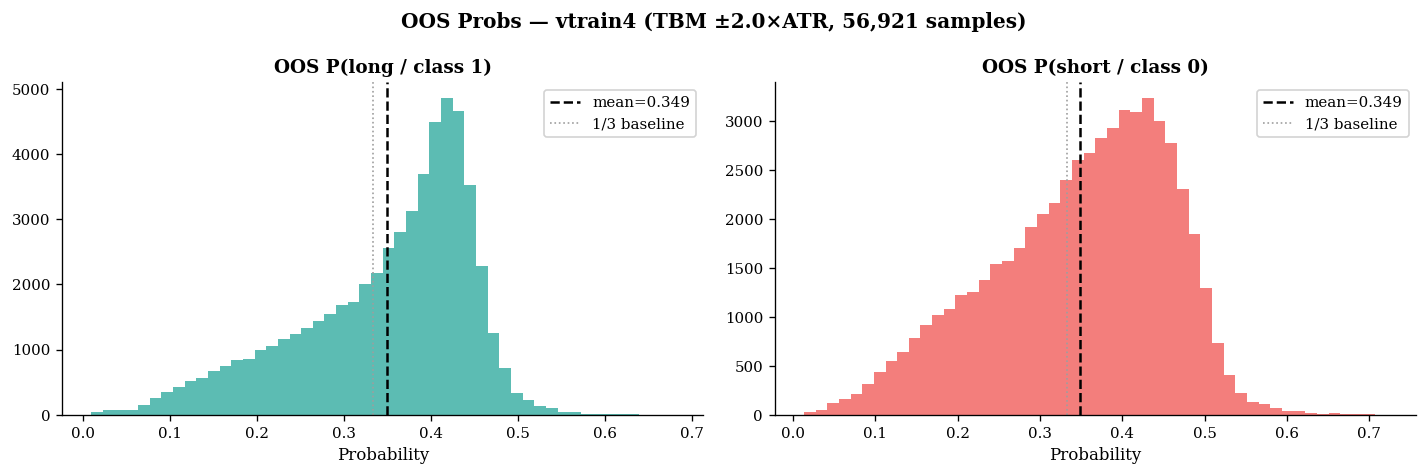

In [7]:
valid_mask  = ~np.isnan(oos_up)
oos_up_v    = oos_up[valid_mask]
oos_down_v  = oos_down[valid_mask]
oos_close_v = train_close[valid_mask]
oos_high_v  = train_high[valid_mask]
oos_low_v   = train_low[valid_mask]
oos_atr_v   = train_atr[valid_mask]
oos_index_v = train_index[valid_mask]
bh_oos      = oos_close_v / oos_close_v[0]

print(f'OOS rows: {len(oos_up_v):,}  range: {oos_index_v.min().date()} → {oos_index_v.max().date()}')
print(f'P(up)   mean={oos_up_v.mean():.4f}  std={oos_up_v.std():.4f}')
print(f'P(down) mean={oos_down_v.mean():.4f}  std={oos_down_v.std():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, prob, label, color in [
    (axes[0], oos_up_v,   'OOS P(long / class 1)',  GREEN),
    (axes[1], oos_down_v, 'OOS P(short / class 0)', RED),
]:
    ax.hist(prob, bins=50, color=color, alpha=0.75, edgecolor='none')
    ax.axvline(prob.mean(), color='black', ls='--', lw=1.5, label=f'mean={prob.mean():.3f}')
    ax.axvline(1/3, color=GREY, ls=':', lw=1, label='1/3 baseline')
    ax.set_xlabel('Probability'); ax.legend()
    ax.set_title(label, fontweight='bold')
fig.suptitle(f'OOS Probs — vtrain4 (TBM ±{TBM_ATR_MULT}×ATR, {len(oos_up_v):,} samples)', fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'tcn_oos_prob_distribution_vtrain4.png'); plt.show()

## Phase 2 — Grid Search: Spot/Futures Routing

Applied to OOS training-set probabilities (no test data touched).

**Key differences vs vtrain3:**
- Longs routed to Spot: `spot_fund=0.0` (no funding drag on longs)
- Shorts routed to Futures: `short_fund=+0.00077%/h` (receive funding)
- Confidence exit aligned with vtrain7: `exit_long = 1 − long_threshold`
- Trading grid includes thresholds up to 0.55 (wider than vtrain3's 0.50 ceiling)

In [8]:
def run_backtest_v4(
    probs_up, probs_down, close_arr, high_arr, low_arr, atr_arr,
    params,
    maker_fee=MAKER_FEE,
    spot_taker=SPOT_TAKER_FEE, fut_taker=FUTURES_TAKER_FEE,
    buf=BUFFER,
    spot_fund=SPOT_FUNDING_H, short_fund=SHORT_FUNDING_H
):
    """Spot/Futures routing backtester (aligned with LGBM vtrain7).

    Longs  (Spot)    : maker entry, spot_taker on SL/max_hold/conf exits, 0% funding drag
    Shorts (Futures) : maker entry, fut_taker  on SL/max_hold/conf exits, +short_fund/h RECEIVED
    TP exits         : maker_fee (both sides)
    Confidence exit  : exit_long = 1 - long_threshold  (vtrain7 convention)
    """
    lt         = params['long_threshold']
    st         = params['short_threshold']
    exit_long  = 1.0 - lt    # vtrain7 convention: symmetric around 0.5
    exit_short = 1.0 - st
    ent_atr    = params['entry_atr_mult']
    sl_m       = params['sl_atr_multiplier']
    tp_m       = params['tp_atr_multiplier']
    min_sl     = params['min_sl']
    min_hold   = int(params['min_hold'])
    max_hold   = int(params['max_hold'])
    cd_n       = int(params['cooldown'])

    cash = 1.0; units = 0.0; entry_cash = 0.0
    in_pos = False; direction = None
    entry_px = 0.0; dsl = 0.0; dtp = 0.0
    hold_count = 0; cooldown = 0; entry_bar = -1
    pending = None

    equity = [1.0]; trade_log = []
    n_sig = 0; n_fill = 0; n_exp = 0

    N = len(close_arr)
    for i in range(N):
        px  = close_arr[i]; hi = high_arr[i]; lo = low_arr[i]
        pup = probs_up[i];  pdn = probs_down[i]; atr = atr_arr[i]
        if cooldown > 0: cooldown -= 1

        # ── 1. Fill check (TIF = 1 bar) ─────────────────────────────────────
        if pending is not None:
            lp = pending['limit_px']
            if pending['direction'] == 'long':
                if lo < lp * (1.0 - buf):
                    units = cash * (1.0 - maker_fee) / lp; cash = 0.0
                    in_pos = True; direction = 'long'; entry_px = lp
                    entry_bar = i; hold_count = 0; dsl = pending['sl']; dtp = pending['tp']
                    n_fill += 1
                else: n_exp += 1
            else:
                if hi > lp * (1.0 + buf):
                    entry_cash = cash * (1.0 - maker_fee); cash = 0.0; units = entry_cash / lp
                    in_pos = True; direction = 'short'; entry_px = lp
                    entry_bar = i; hold_count = 0; dsl = pending['sl']; dtp = pending['tp']
                    n_fill += 1
                else: n_exp += 1
            pending = None

        # ── 2. Manage open position ─────────────────────────────────────────
        if in_pos and i > entry_bar:
            hold_count += 1
            if direction == 'long':
                units      *= (1.0 - spot_fund)    # Spot: zero drag (spot_fund=0.0)
            else:
                entry_cash *= (1.0 + short_fund)   # Futures short: receive funding

            reason = None; exit_px = px; pnl = 0.0

            if direction == 'long':
                sl_price = entry_px * (1.0 - dsl)
                tp_price = entry_px * (1.0 + dtp)
                tp_check = tp_price * (1.0 + buf)
                sl_hit = lo <= sl_price; tp_hit = hi > tp_check
                if sl_hit and tp_hit:    reason = 'sl'; exit_px = sl_price
                elif sl_hit:             reason = 'sl'; exit_px = sl_price
                elif tp_hit:             reason = 'tp'; exit_px = tp_price
                elif hold_count >= max_hold: reason = 'max_hold'
                elif hold_count >= min_hold and pup < exit_long: reason = 'conf'
                if reason:
                    pnl = (exit_px - entry_px) / entry_px
                    fe  = spot_taker if reason != 'tp' else maker_fee
                    cash = units * exit_px * (1.0 - fe); units = 0.0
            else:
                sl_price = entry_px * (1.0 + dsl)
                tp_price = entry_px * (1.0 - dtp)
                tp_check = tp_price * (1.0 - buf)
                sl_hit = hi >= sl_price; tp_hit = lo < tp_check
                if sl_hit and tp_hit:    reason = 'sl'; exit_px = sl_price
                elif sl_hit:             reason = 'sl'; exit_px = sl_price
                elif tp_hit:             reason = 'tp'; exit_px = tp_price
                elif hold_count >= max_hold: reason = 'max_hold'
                elif hold_count >= min_hold and pdn < exit_short: reason = 'conf'
                if reason:
                    gross = (entry_px - exit_px) / entry_px; pnl = gross
                    fe    = fut_taker if reason != 'tp' else maker_fee
                    cash  = entry_cash * (1.0 + gross) * (1.0 - fe)

            if reason:
                trade_log.append({'direction': direction, 'pnl_pct': pnl,
                                   'hold_h': hold_count, 'reason': reason})
                in_pos = False; hold_count = 0; cooldown = cd_n

        # ── 3. Place pending order if flat ───────────────────────────────────
        if not in_pos and pending is None and cooldown == 0:
            sl_v = max(sl_m * atr, min_sl); tp_v = tp_m * atr
            if pup >= lt:
                pending = {'direction': 'long',  'limit_px': px - ent_atr*atr, 'sl': sl_v, 'tp': tp_v}
                n_sig += 1
            elif pdn >= st and pup < lt:
                pending = {'direction': 'short', 'limit_px': px + ent_atr*atr, 'sl': sl_v, 'tp': tp_v}
                n_sig += 1

        # ── Equity ───────────────────────────────────────────────────────────
        if in_pos and direction == 'long':    equity.append(units * px)
        elif in_pos and direction == 'short': equity.append(entry_cash * (1.0 + (entry_px - px) / entry_px))
        else:                                 equity.append(cash)

    if in_pos:
        px = close_arr[-1]
        if direction == 'long':
            gross = (px - entry_px) / entry_px; cash = units * px * (1 - spot_taker)
        else:
            gross = (entry_px - px) / entry_px; cash = entry_cash * (1 + gross) * (1 - fut_taker)
        trade_log.append({'direction': direction, 'pnl_pct': gross, 'hold_h': hold_count, 'reason': 'eod'})
        equity[-1] = cash

    tdf = pd.DataFrame(trade_log)
    tdf.attrs = {'n_signals': n_sig, 'n_fills': n_fill, 'n_expires': n_exp}
    return np.array(equity[1:]), tdf


def score_eq(eq, tdf, metric):
    if tdf.empty: return -np.inf
    r = np.log(np.maximum(eq[1:],1e-12)/np.maximum(eq[:-1],1e-12)); ann = 24*365
    if metric == 'sharpe':       return float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(ann))
    if metric == 'total_return': return float(eq[-1]-1)
    if metric == 'calmar':
        ar = float((eq[-1]**(ann/len(eq)))-1); pk = np.maximum.accumulate(eq)
        return ar/(abs(float(((eq-pk)/(pk+1e-12)).min()))+1e-6)
    if metric == 'win_rate': return float((tdf['pnl_pct']>0).mean())
    return -np.inf

print('run_backtest_v4() defined.')

run_backtest_v4() defined.


In [9]:
keys   = list(TRADING_GRID.keys())
combos = list(itertools.product(*[TRADING_GRID[k] for k in keys]))
print(f'Grid combinations: {len(combos):,}')

results = []
for vals in tqdm(combos, desc='Grid search (OOS, Spot/Fut routing)', ncols=80):
    p = dict(zip(keys, vals))
    eq, tdf = run_backtest_v4(
        oos_up_v, oos_down_v, oos_close_v, oos_high_v, oos_low_v, oos_atr_v, p)
    if len(tdf) < MIN_TRADES: continue

    s  = score_eq(eq, tdf, OPTIMISE_METRIC)
    r  = np.log(np.maximum(eq[1:],1e-12)/np.maximum(eq[:-1],1e-12))
    pk = np.maximum.accumulate(eq)
    fr = tdf.attrs['n_fills'] / max(tdf.attrs['n_signals'], 1)

    results.append({
        **p,
        'score':        s,
        'total_return': float(eq[-1]-1),
        'sharpe':       float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(24*365)),
        'max_dd':       float(((eq-pk)/(pk+1e-12)).min()),
        'n_trades':     len(tdf),
        'win_rate':     float((tdf['pnl_pct']>0).mean()),
        'n_long':       int((tdf['direction']=='long').sum()),
        'n_short':      int((tdf['direction']=='short').sum()),
        'n_sl':         int((tdf['reason']=='sl').sum()),
        'n_tp':         int((tdf['reason']=='tp').sum()),
        'fill_rate':    fr,
    })

results_df = pd.DataFrame(results).sort_values('score', ascending=False).reset_index(drop=True)
print(f'\nValid (≥{MIN_TRADES} trades): {len(results_df):,}/{len(combos):,}')
if not results_df.empty:
    print(f'Best {OPTIMISE_METRIC}    : {results_df["score"].iloc[0]:.4f}')
    print(f'Fill rate     : mean={results_df["fill_rate"].mean():.1%}')

Grid combinations: 6,912


Grid search (OOS, Spot/Fut routing): 100%|██| 6912/6912 [02:40<00:00, 43.08it/s]


Valid (≥15 trades): 6,912/6,912
Best sharpe    : 0.7809
Fill rate     : mean=86.8%


In [10]:
from IPython.display import display

disp = ['score','total_return','sharpe','max_dd','win_rate','fill_rate',
        'n_trades','n_long','n_short','n_sl','n_tp',
        'long_threshold','short_threshold','entry_atr_mult',
        'sl_atr_multiplier','tp_atr_multiplier','min_sl','min_hold','max_hold','cooldown']
top = results_df[disp].head(TOP_N).copy()
for col, fmt in [('total_return','{:+.2%}'),('max_dd','{:.2%}'),('win_rate','{:.1%}'),
                 ('fill_rate','{:.1%}'),('score','{:.4f}'),('sharpe','{:.3f}')]:
    top[col] = top[col].map(fmt.format)

best        = results_df.iloc[0]
best_params = {k: best[k] for k in keys}

print(f'Top {TOP_N} by {OPTIMISE_METRIC}  (TCN vtrain4 — Spot/Fut routing):\n')
print(top.to_string(index=True))
print(f'\n── Best config ──────────────────────────────────────────')
for k, v in best_params.items(): print(f'  {k:<24}: {v}')
print(f'  {"OOS Sharpe":<24}: {best["sharpe"]:.4f}')
print(f'  {"OOS Return":<24}: {best["total_return"]:+.2%}')
print(f'  {"OOS MaxDD":<24}: {best["max_dd"]:.2%}')
print(f'  {"OOS Trades":<24}: {int(best["n_trades"])}  (fill rate: {best["fill_rate"]:.1%})')

Top 20 by sharpe  (TCN vtrain4 — Spot/Fut routing):

     score total_return sharpe   max_dd win_rate fill_rate  n_trades  n_long  n_short  n_sl  n_tp  long_threshold  short_threshold  entry_atr_mult  sl_atr_multiplier  tp_atr_multiplier  min_sl  min_hold  max_hold  cooldown
0   0.7809     +109.82%  0.781  -18.24%    46.7%     84.1%       646      38      608   213   148            0.55              0.5             1.0                1.5                3.0   0.010         8        24         3
1   0.7809     +109.82%  0.781  -18.24%    46.7%     84.1%       646      38      608   213   148            0.55              0.5             1.0                1.5                3.0   0.010         8        48         3
2   0.7809     +109.81%  0.781  -18.24%    46.7%     84.1%       646      38      608   213   148            0.55              0.5             0.6                1.5                3.0   0.010         8        24         3
3   0.7809     +109.81%  0.781  -18.24%    46.7%     84

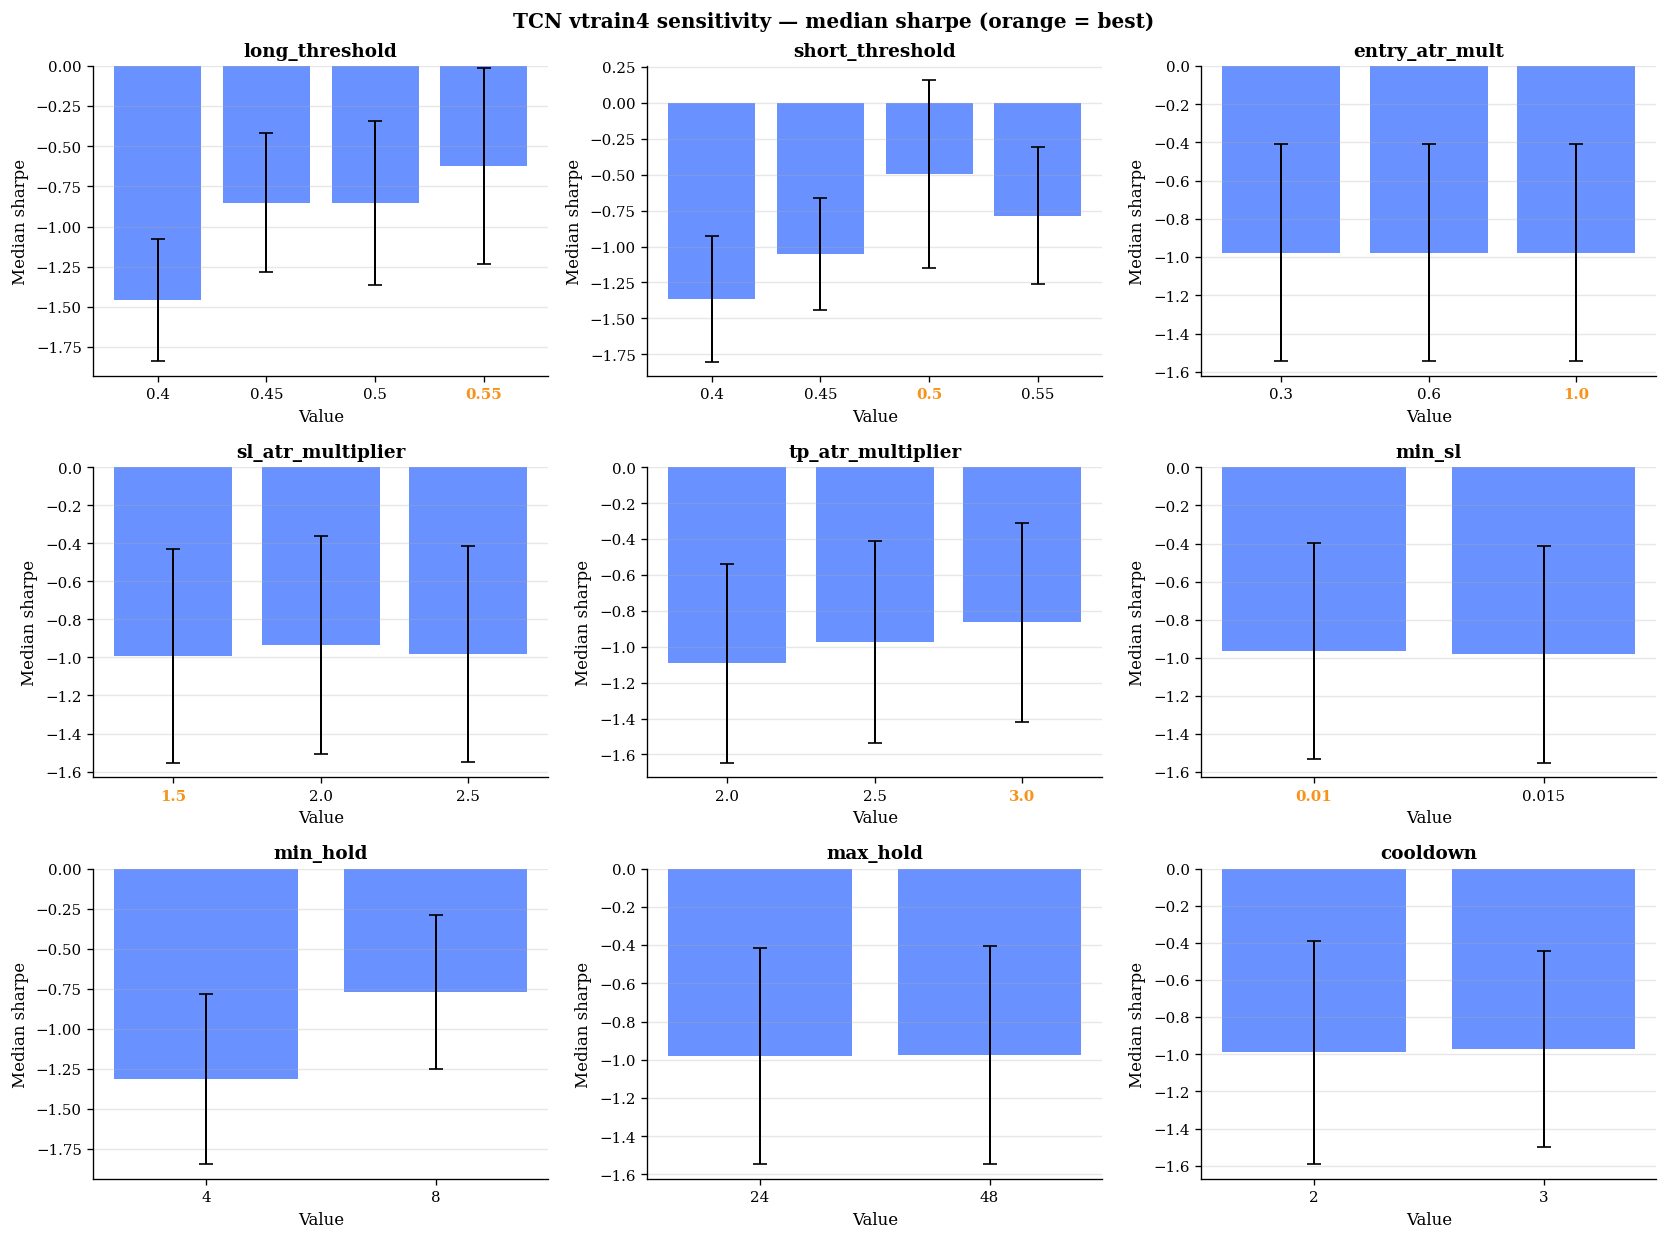

In [11]:
if not results_df.empty:
    n_p = len(keys); ncols = 3; nrows = int(np.ceil(n_p / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows*3.5))
    for ax, param in zip(axes.flat, keys):
        grp = results_df.groupby(param)['score'].agg(['median','std']).reset_index()
        x   = grp[param].astype(str)
        ax.bar(x, grp['median'], color=BLUE, alpha=0.7)
        ax.errorbar(x, grp['median'], yerr=grp['std'],
                    fmt='none', color='black', capsize=4, lw=1.2)
        ax.set_title(param, fontweight='bold')
        ax.set_xlabel('Value'); ax.set_ylabel(f'Median {OPTIMISE_METRIC}')
        ax.grid(axis='y', alpha=0.3)
        bv = str(best[param])
        for tick in ax.get_xticklabels():
            if tick.get_text() == bv: tick.set_color(ACCENT); tick.set_fontweight('bold')
    for ax in axes.flat[n_p:]: ax.set_visible(False)
    fig.suptitle(f'TCN vtrain4 sensitivity — median {OPTIMISE_METRIC} (orange = best)', fontweight='bold')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'tcn_grid_sensitivity_vtrain4.png'); plt.show()

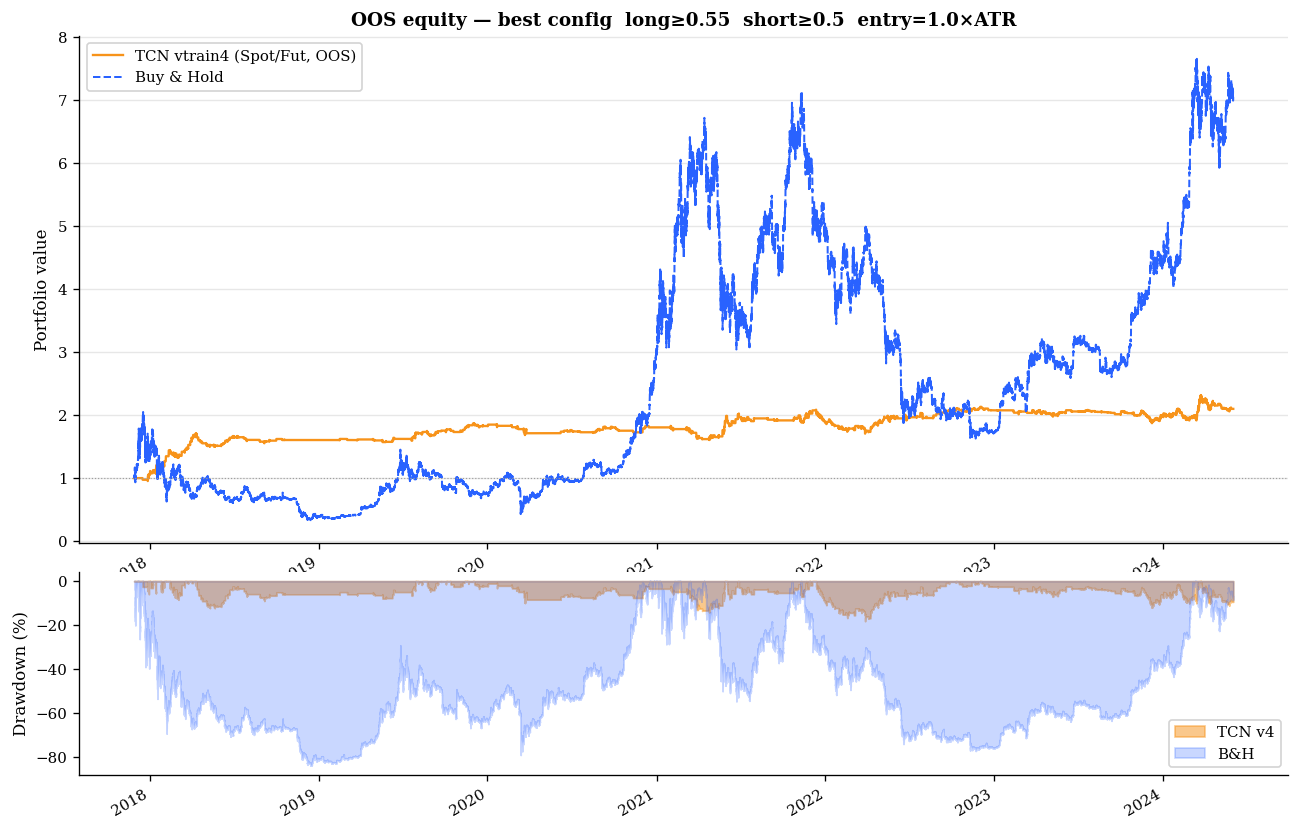

OOS  Sharpe=0.781  Return=+109.82%  MaxDD=-18.24%  Trades=646  FillRate=84.1%


In [12]:
if not results_df.empty:
    eq_oos, tdf_oos = run_backtest_v4(
        oos_up_v, oos_down_v, oos_close_v, oos_high_v, oos_low_v, oos_atr_v, best_params)

    fig, axes = plt.subplots(2, 1, figsize=(13, 8),
                              gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08})
    ax = axes[0]
    ax.plot(oos_index_v, eq_oos, color=ACCENT, lw=1.4, label='TCN vtrain4 (Spot/Fut, OOS)')
    ax.plot(oos_index_v, bh_oos, color=BLUE, lw=1.2, ls='--', label='Buy & Hold')
    ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
    ax.set_ylabel('Portfolio value')
    ax.set_title(f'OOS equity — best config  long≥{best_params["long_threshold"]}  '
                 f'short≥{best_params["short_threshold"]}  '
                 f'entry={best_params["entry_atr_mult"]}×ATR', fontweight='bold')
    ax.legend(); ax.grid(axis='y', alpha=0.3)

    ax = axes[1]
    pk_s = np.maximum.accumulate(eq_oos); pk_b = np.maximum.accumulate(bh_oos)
    ax.fill_between(oos_index_v, (eq_oos-pk_s)/(pk_s+1e-12)*100, 0, color=ACCENT, alpha=0.5, label='TCN v4')
    ax.fill_between(oos_index_v, (bh_oos-pk_b)/(pk_b+1e-12)*100, 0, color=BLUE,  alpha=0.25, label='B&H')
    ax.set_ylabel('Drawdown (%)'); ax.legend()
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / 'tcn_grid_oos_equity_vtrain4.png'); plt.show()

    rr = np.log(np.maximum(eq_oos[1:],1e-12)/np.maximum(eq_oos[:-1],1e-12))
    pk = np.maximum.accumulate(eq_oos)
    print(f'OOS  Sharpe={rr.mean()/(rr.std(ddof=1)+1e-12)*np.sqrt(24*365):.3f}  '
          f'Return={eq_oos[-1]-1:+.2%}  MaxDD={((eq_oos-pk)/(pk+1e-12)).min():.2%}  '
          f'Trades={len(tdf_oos)}  FillRate={tdf_oos.attrs["n_fills"]/max(tdf_oos.attrs["n_signals"],1):.1%}')

## Phase 3 — Train Production Model + Test Evaluation

Train a single production model on the full training set using the vtrain4 TBM labels (±2×ATR, 24h).
Architecture is identical to vtrain3. Evaluate on the held-out test set with best trading params.

**vtrain history for comparison:**
| Version | Execution | Trades | Return | Sharpe |
|---------|-----------|--------|--------|--------|
| vtrain1 | Close-only SL/TP, 0% fees | 75 | +11.68% | 0.446 |
| vtrain2 static | TBM 1×σ, 0.1% taker | 205 | −34.00% | −4.006 |
| vtrain2 WFO   | TBM 1×σ, 5-ep retrain, 0.1% | 933 | −88.52% | −10.703 |
| vtrain3 maker | TBM 1×σ, maker entry, asym fees | 620 | −71.55% | −2.602 |
| **vtrain4** | **TBM ±2×ATR, Spot/Fut routing** | — | — | — |

In [16]:
if results_df.empty:
    raise RuntimeError('Grid search produced no results — cannot train production model.')

print('Training production model on full train_df with vtrain4 TBM labels...')

# Fit QT on full train set and persist it
qt_prod = QuantileTransformer(output_distribution='normal', n_quantiles=1000, random_state=SEED)
qt_prod.fit(train_df[ALL_INPUT_FEATS].values)
X_prod_qt = qt_prod.transform(train_df[ALL_INPUT_FEATS].values).astype(np.float32)

y_prod = train_df['tbm_label'].values.astype(np.int64)
w_prod = train_df['sample_weight'].values.astype(np.float32)
v_prod = train_df['fwd_vol'].values.astype(np.float32)

# Build full-train sequences
X_fs, y_fs, w_fs, v_fs = [], [], [], []
for i in range(SEQ_LEN-1, len(X_prod_qt)):
    X_fs.append(X_prod_qt[i-SEQ_LEN+1:i+1])
    y_fs.append(y_prod[i]); w_fs.append(w_prod[i]); v_fs.append(v_prod[i])
X_full = torch.tensor(np.array(X_fs, dtype=np.float32))
y_full = torch.tensor(np.array(y_fs, dtype=np.int64))
w_full = torch.tensor(np.array(w_fs, dtype=np.float32))
v_full = torch.tensor(np.array(v_fs, dtype=np.float32))
print(f'Full-train sequences: {len(X_full):,}')

ccs = np.bincount(y_full.numpy(), minlength=3).astype(np.float32)
cw  = torch.tensor(ccs.sum()/(3*ccs+1e-8), dtype=torch.float32).to(DEVICE)

# Use val_df for early stopping
# Val sequences: sequence j covers rows j..j+SEQ_LEN-1 → label is at row j+SEQ_LEN-1.
# np.stack with range(N-SEQ_LEN+1) produces N-SEQ_LEN+1 sequences.
# Labels/fwd_vol must start at SEQ_LEN-1 (not SEQ_LEN) to match that count.
X_val_raw  = qt_prod.transform(val_df[ALL_INPUT_FEATS].values).astype(np.float32)
X_val_seqs = np.stack([X_val_raw[i:i+SEQ_LEN]
                        for i in range(len(X_val_raw)-SEQ_LEN+1)]).astype(np.float32)
y_val_prod = val_df['tbm_label'].values[SEQ_LEN-1:].astype(np.int64)
v_val_prod = val_df['fwd_vol'].values[SEQ_LEN-1:].astype(np.float32)
assert len(X_val_seqs) == len(y_val_prod) == len(v_val_prod), \
    f'Val size mismatch: X={len(X_val_seqs)} y={len(y_val_prod)} v={len(v_val_prod)}'
X_val_t = torch.from_numpy(X_val_seqs)
y_val_t = torch.from_numpy(y_val_prod)
v_val_t = torch.from_numpy(v_val_prod)
print(f'Val sequences: {len(X_val_t):,}')

EPOCHS_PROD = 80
model_prod  = TCNMultiTask(len(ALL_INPUT_FEATS), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).to(DEVICE)
opt_prod    = torch.optim.AdamW(model_prod.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched_prod  = torch.optim.lr_scheduler.LambdaLR(
    opt_prod, lr_lambda=make_lr_lambda(EPOCHS_PROD, WARMUP_EPOCHS))

loader_full = DataLoader(TensorDataset(X_full, y_full, w_full, v_full),
                          batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=0)
loader_val  = DataLoader(TensorDataset(X_val_t, y_val_t,
                                        torch.ones(len(y_val_t)), v_val_t),
                          batch_size=512, shuffle=False, num_workers=0)

PATIENCE_PROD = 15; best_val = np.inf; pat = 0; best_prod_state = None
for epoch in range(EPOCHS_PROD):
    model_prod.train()
    for xb, yb, wb, vb in loader_full:
        xb,yb,wb,vb = xb.to(DEVICE),yb.to(DEVICE),wb.to(DEVICE),vb.to(DEVICE)
        opt_prod.zero_grad()
        lgts, vp = model_prod(xb)
        loss = (F.cross_entropy(lgts,yb,weight=cw,reduction='none')*wb).mean() + \
               LAMBDA_VOL*(F.huber_loss(vp,vb,reduction='none')*wb).mean()
        loss.backward(); torch.nn.utils.clip_grad_norm_(model_prod.parameters(),1.0); opt_prod.step()
    sched_prod.step()
    model_prod.eval(); va = 0.0
    with torch.no_grad():
        for xb,yb,_,vb in loader_val:
            xb,yb,vb = xb.to(DEVICE),yb.to(DEVICE),vb.to(DEVICE)
            lgts,vp  = model_prod(xb)
            va += (F.cross_entropy(lgts,yb)+LAMBDA_VOL*F.huber_loss(vp,vb)).item()*len(xb)
    vl = va / max(len(loader_val.dataset), 1)
    if vl < best_val: best_val=vl; best_prod_state={kk:vv.cpu().clone() for kk,vv in model_prod.state_dict().items()}; pat=0
    else: pat+=1
    if pat >= PATIENCE_PROD: print(f'Early stop ep {epoch+1}  best_val={best_val:.5f}'); break
    if (epoch+1)%10==0: print(f'Ep {epoch+1}/{EPOCHS_PROD}  val={vl:.5f}  best={best_val:.5f}  pat={pat}')

model_prod.load_state_dict(best_prod_state)

# Save production model and QT
torch.save(model_prod.state_dict(), MODELS_DIR / 'tcn_model_vtrain4.pt')
with open(MODELS_DIR / 'tcn_qt_vtrain4.pkl', 'wb') as f: pickle.dump(qt_prod, f)
print(f'Saved: tcn_model_vtrain4.pt  tcn_qt_vtrain4.pkl')
model_prod.cpu();
if DEVICE.type=='mps': torch.mps.empty_cache()

Training production model on full train_df with vtrain4 TBM labels...
Full-train sequences: 56,926


AssertionError: Size mismatch between tensors

In [ ]:
# Load production model for test inference
prod_model = TCNMultiTask(len(ALL_INPUT_FEATS), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).to(DEVICE)
prod_model.load_state_dict(torch.load(MODELS_DIR / 'tcn_model_vtrain4.pt', map_location=DEVICE))
prod_model.eval()

qt_test   = pickle.loads((MODELS_DIR / 'tcn_qt_vtrain4.pkl').read_bytes())
X_test_raw = qt_test.transform(test_df[ALL_INPUT_FEATS].values).astype(np.float32)
test_seqs  = np.stack([X_test_raw[i:i+SEQ_LEN] for i in range(len(X_test_raw)-SEQ_LEN+1)],
                       axis=0).astype(np.float32)
ll = []
with torch.no_grad():
    for xb, in DataLoader(TensorDataset(torch.from_numpy(test_seqs)), batch_size=512):
        lgts, _ = prod_model(xb.to(DEVICE)); ll.append(lgts.cpu())
probs_test = torch.softmax(torch.cat(ll), dim=1).numpy()
test_up    = probs_test[:, 1].astype(np.float32)
test_down  = probs_test[:, 0].astype(np.float32)

test_close_v = test_df['close'].values[SEQ_LEN:].astype(np.float64)
test_high_v  = test_df['high'].values[SEQ_LEN:].astype(np.float64)
test_low_v   = test_df['low'].values[SEQ_LEN:].astype(np.float64)
test_atr_v   = test_df['atr_14_pct'].values[SEQ_LEN:].astype(np.float64)
test_index_v = test_df.index[SEQ_LEN:]
test_bh      = test_close_v / test_close_v[0]

prod_model.cpu(); del prod_model
if DEVICE.type=='mps': torch.mps.empty_cache()
print(f'Test sequences: {len(test_up):,}  period: {test_index_v.min().date()} → {test_index_v.max().date()}')

# ── vtrain4 test backtest ─────────────────────────────────────────────────────
eq_v4, tdf_v4 = run_backtest_v4(
    test_up, test_down, test_close_v, test_high_v, test_low_v, test_atr_v, best_params)

def full_metrics(eq, tdf, label):
    r  = np.log(np.maximum(eq[1:],1e-12)/np.maximum(eq[:-1],1e-12))
    pk = np.maximum.accumulate(eq)
    sh = float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(24*365))
    mdd = float(((eq-pk)/(pk+1e-12)).min())
    an  = float((eq[-1]**(24*365/len(eq)))-1)
    wr  = float((tdf['pnl_pct']>0).mean()) if not tdf.empty else float('nan')
    pf  = 0.0
    if not tdf.empty:
        g = tdf[tdf['pnl_pct']>0]['pnl_pct'].sum(); l = tdf[tdf['pnl_pct']<0]['pnl_pct'].abs().sum()
        pf = g/(l+1e-6)
    fr = tdf.attrs.get('n_fills',0)/max(tdf.attrs.get('n_signals',1),1) if tdf.attrs else float('nan')
    return {
        'Strategy':      label,
        'Total Return':  f'{eq[-1]-1:+.2%}',
        'Ann. Return':   f'{an:+.2%}',
        'Sharpe (ann.)': f'{sh:.3f}',
        'Max Drawdown':  f'{mdd:.2%}',
        'Win Rate':      f'{wr:.1%}' if not np.isnan(wr) else 'N/A',
        'Profit Factor': f'{pf:.3f}',
        'Trades':        str(len(tdf)),
    }

summary = pd.DataFrame([
    {'Strategy': 'vtrain1 ref   (close-only, 0% fees)',                  'Total Return': '+11.68%', 'Ann. Return': 'N/A', 'Sharpe (ann.)': '0.446',  'Max Drawdown': '-19.08%', 'Win Rate': '60.0%', 'Profit Factor': 'N/A', 'Trades': '75'},
    {'Strategy': 'vtrain2 static (TBM 1×σ, 0.1% flat)',                  'Total Return': '-34.00%', 'Ann. Return': 'N/A', 'Sharpe (ann.)': '-4.006', 'Max Drawdown': '-34.54%', 'Win Rate': '52.7%', 'Profit Factor': 'N/A', 'Trades': '205'},
    {'Strategy': 'vtrain2 WFO   (TBM 1×σ, 5-ep retrain, 0.1% flat)',    'Total Return': '-88.52%', 'Ann. Return': 'N/A', 'Sharpe (ann.)': '-10.703','Max Drawdown': '-88.56%', 'Win Rate': '46.9%', 'Profit Factor': 'N/A', 'Trades': '933'},
    {'Strategy': 'vtrain3 maker (TBM 1×σ, maker entry, asym fees)',      'Total Return': '-71.55%', 'Ann. Return': 'N/A', 'Sharpe (ann.)': '-2.602', 'Max Drawdown': '-74.03%', 'Win Rate': '48.2%', 'Profit Factor': 'N/A', 'Trades': '620'},
    full_metrics(eq_v4, tdf_v4, f'vtrain4 (TBM ±{TBM_ATR_MULT}×ATR, Spot/Fut routing)'),
    full_metrics(test_bh, pd.DataFrame(), 'Buy & Hold'),
]).set_index('Strategy')

print('\n' + '='*90)
print('  FINAL TEST-SET SUMMARY — TCN vtrain4')
print('='*90)
print(summary.to_string())
print('='*90)

if not tdf_v4.empty:
    print(f'\n  vtrain4 exit breakdown:')
    for r, grp in tdf_v4.groupby('reason'):
        wr_r = (grp['pnl_pct']>0).mean()*100
        print(f'    {r:<12}  n={len(grp):>3}  win={wr_r:.1f}%  avg={grp["pnl_pct"].mean()*100:+.2f}%')
    long_trades  = tdf_v4[tdf_v4['direction']=='long']
    short_trades = tdf_v4[tdf_v4['direction']=='short']
    print(f'\n  Long/Short split: {len(long_trades)} longs / {len(short_trades)} shorts')
    if len(long_trades):  print(f'    Long  avg P&L: {long_trades["pnl_pct"].mean()*100:+.2f}%')
    if len(short_trades): print(f'    Short avg P&L: {short_trades["pnl_pct"].mean()*100:+.2f}%')
    print(f'  Fill rate: {tdf_v4.attrs["n_fills"]}/{tdf_v4.attrs["n_signals"]} signals = '
          f'{tdf_v4.attrs["n_fills"]/max(tdf_v4.attrs["n_signals"],1):.1%}')

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9),
                          gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.10})
ax = axes[0]
ax.plot(test_index_v, eq_v4,   color=ACCENT, lw=1.6, label=f'vtrain4 (TBM ±{TBM_ATR_MULT}×ATR, Spot/Fut)')
ax.plot(test_index_v, test_bh, color=BLUE,   lw=1.2, ls='--', label='Buy & Hold')
ax.axhline(1.0, color=GREY, lw=0.7, ls=':')
ax.set_ylabel('Portfolio value')
ax.set_title('TCN vtrain4 — Wider TBM Labels + Spot/Futures Routing', fontweight='bold')
ax.legend(ncol=2); ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

ax = axes[1]
for eq, idx, color, lbl in [
    (eq_v4,   test_index_v, ACCENT, 'vtrain4'),
    (test_bh, test_index_v, BLUE,   'B&H'),
]:
    pk = np.maximum.accumulate(eq)
    ax.fill_between(idx, (eq-pk)/(pk+1e-12)*100, 0, alpha=0.35, label=lbl)
ax.set_ylabel('Drawdown (%)'); ax.legend(ncol=2)
ax.grid(axis='y', alpha=0.3); ax.grid(axis='x', alpha=0.15)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.text(0.5, 0.005,
    f'TBM ±{TBM_ATR_MULT}×ATR {TBM_VERT_H}h  '
    f'entry={best_params["entry_atr_mult"]}×ATR  SL={best_params["sl_atr_multiplier"]}×ATR  '
    f'TP={best_params["tp_atr_multiplier"]}×ATR  min_sl={best_params["min_sl"]*100:.1f}%  '
    f'long≥{best_params["long_threshold"]}  short≥{best_params["short_threshold"]}  '
    f'hold={best_params["min_hold"]}–{best_params["max_hold"]}h  '
    f'maker={MAKER_FEE*100:.2f}%  spotTaker={SPOT_TAKER_FEE*100:.3f}%  futTaker={FUTURES_TAKER_FEE*100:.3f}%',
    ha='center', fontsize=8, color=GREY, style='italic')
fig.savefig(FIGURES_DIR / 'tcn_backtest_results_vtrain4.png'); plt.show()

In [ ]:
if not results_df.empty:
    out_csv = MODELS_DIR / 'tcn_grid_results_vtrain4.csv'
    results_df.sort_values(OPTIMISE_METRIC, ascending=False).to_csv(out_csv, index=False)
    print(f'Saved: {out_csv}')

    def _s(eq): r=np.log(np.maximum(eq[1:],1e-12)/np.maximum(eq[:-1],1e-12)); return float(r.mean()/(r.std(ddof=1)+1e-12)*np.sqrt(24*365))
    def _d(eq): pk=np.maximum.accumulate(eq); return float(((eq-pk)/(pk+1e-12)).min())

    out = {
        'version': 'vtrain4',
        'changes_vs_vtrain3': [
            f'TBM labels: ±{TBM_ATR_MULT}×ATR barriers, {TBM_VERT_H}h vertical (vtrain3 was 1×σ, 12h)',
            'Spot/Futures routing: longs→Spot (0% funding), shorts→Futures (receive +0.00077%/h)',
            'Confidence exit: 1 - threshold (vtrain7 convention; vtrain3 used threshold - 0.10)',
            'Architecture FIXED at vtrain3 best: [64,64,64,64] kernel=3 dropout=0.40 (no arch search)',
            'Trading grid thresholds up to 0.55 (vtrain3 topped at 0.50)',
        ],
        'architecture': {
            'channels': TCN_CHANNELS, 'kernel': TCN_KERNEL, 'dropout': TCN_DROPOUT,
            'seq_len': SEQ_LEN, 'n_params': sum(p.numel() for p in TCNMultiTask(
                len(ALL_INPUT_FEATS), TCN_CHANNELS, TCN_KERNEL, TCN_DROPOUT).parameters()),
        },
        'tbm': {'atr_mult': TBM_ATR_MULT, 'horizon': TBM_VERT_H},
        'execution': {
            'maker_fee': MAKER_FEE, 'spot_taker_fee': SPOT_TAKER_FEE,
            'futures_taker_fee': FUTURES_TAKER_FEE, 'buffer': BUFFER,
            'spot_funding_h': SPOT_FUNDING_H, 'short_funding_h': SHORT_FUNDING_H,
        },
        'best_params': best_params,
        'oos_kfold': {
            'sharpe':       round(float(best['sharpe']), 4),
            'total_return': round(float(best['total_return']), 4),
            'max_dd':       round(float(best['max_dd']), 4),
            'n_trades':     int(best['n_trades']),
            'fill_rate':    round(float(best['fill_rate']), 4),
        },
        'test_static': {
            'sharpe':       round(_s(eq_v4), 4),
            'total_return': round(float(eq_v4[-1]-1), 4),
            'max_dd':       round(_d(eq_v4), 4),
            'n_trades':     int(len(tdf_v4)),
            'fill_rate':    round(tdf_v4.attrs.get('n_fills',0)/max(tdf_v4.attrs.get('n_signals',1),1), 4),
        },
    }

    out_json = MODELS_DIR / 'tcn_best_trading_params_vtrain4.json'
    with open(out_json, 'w') as f: json.dump(out, f, indent=2)
    print(f'Saved: {out_json}')
    print()
    print(json.dumps(out, indent=2))